# II. Lagged price

$$
\text{Price}_t = \alpha + \beta_1 \cdot \text{Time}_t + \beta_2 \cdot \text{Lagged Price}_{t-1} + \beta_3 \cdot \text{News}_t +  \epsilon_t
$$


In the previous notbook we observed that the polynomial regression even in a trending market leaves much to be desired in terms of modeling price. This notebook introduces lagged price as an indicator of future prices.

In [79]:
import pandas as pd
import numpy as np

data = pd.read_csv("../data/raw/eur_usd_trending.csv", index_col="time", parse_dates=True)

data['lagged_price'] = data['close'].shift(1)
data.dropna(inplace=True)

X=data[['lagged_price']].values
y=data['close'].values

print(data.head())


                             close  lagged_price
time                                            
2022-10-02 22:00:00+00:00  0.98010       0.97963
2022-10-02 23:00:00+00:00  0.97936       0.98010
2022-10-03 00:00:00+00:00  0.98014       0.97936
2022-10-03 01:00:00+00:00  0.98258       0.98014
2022-10-03 02:00:00+00:00  0.98124       0.98258


Mean Squared Error: 2.3173906431527248e-06
R-squared Score: 0.9984351977368132


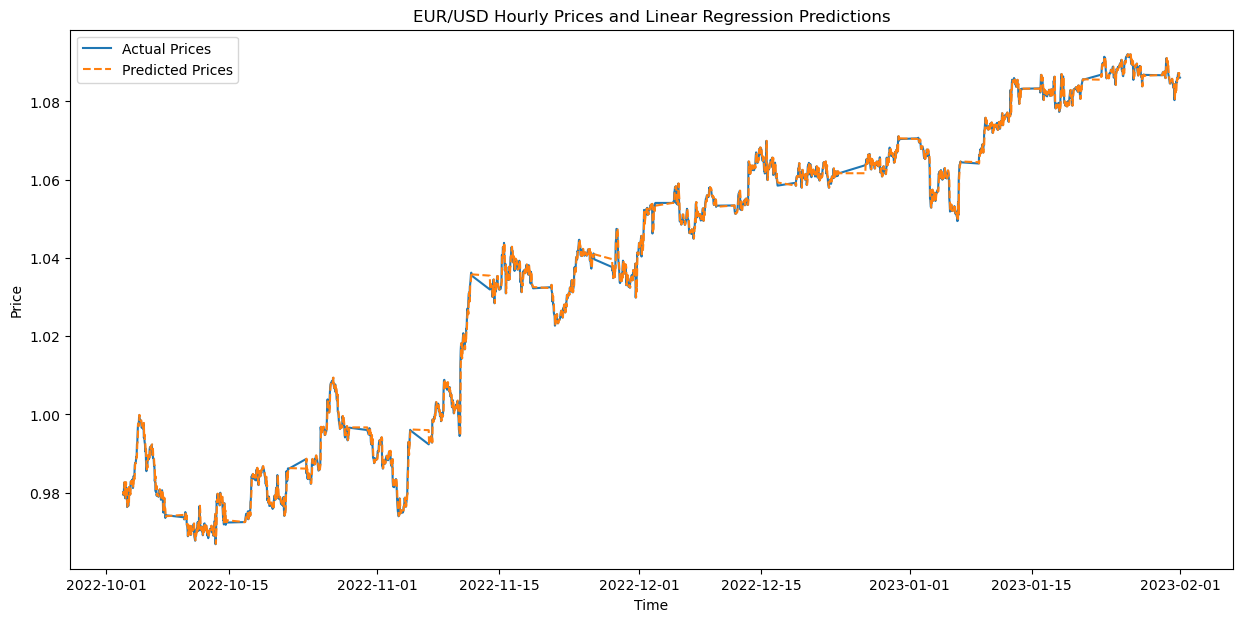

In [81]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X, y)

y_prediction = linear_model.predict(X)
 
mse = mean_squared_error(y, y_prediction)
r2 = r2_score(y, y_prediction)

print(f'Mean Squared Error: {mse}')
print(f'R-squared Score: {r2}')

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(data.index, y, label='Actual Prices')
plt.plot(data.index, y_prediction, label='Predicted Prices', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('EUR/USD Hourly Prices and Linear Regression Predictions')
plt.legend()
plt.show()

Theta: [1.0352776  0.03845296]
Mean Squared Error (GD): 2.317390643155769e-06
R-squared Score (GD): 0.9984351977368112


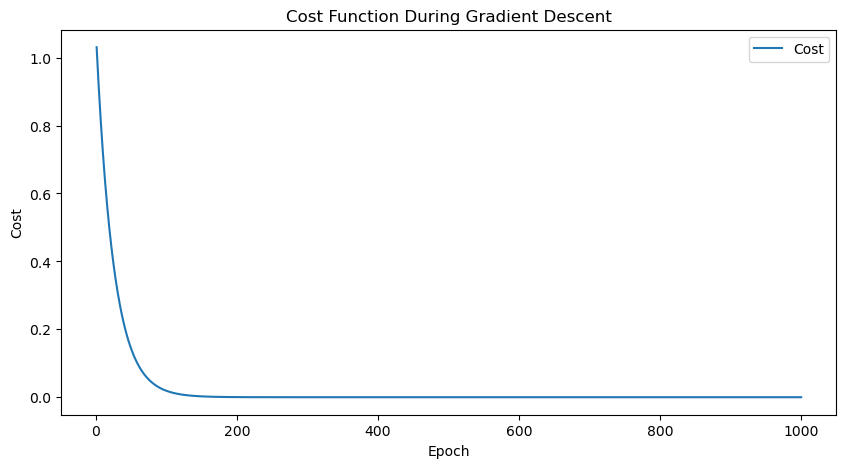

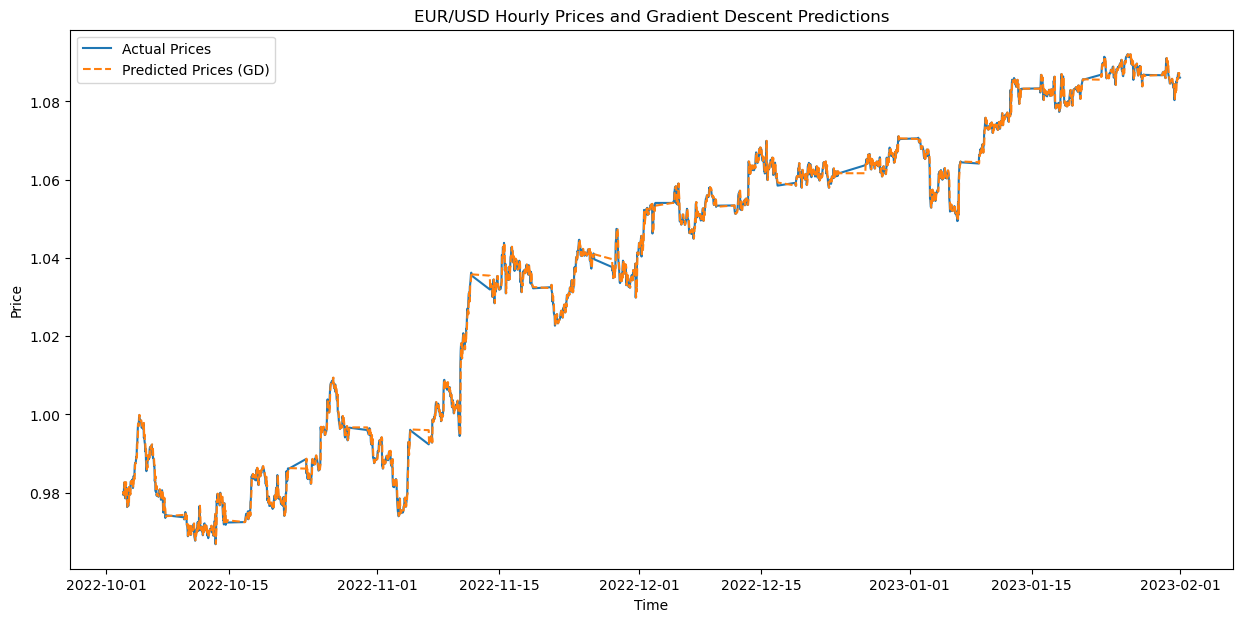

In [83]:
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m = len(y)
    theta = np.zeros(X.shape[1] + 1)  # Add one for the intercept
    X_b = np.c_[np.ones((m, 1)), X]  # Add x0 = 1 to each instance
    cost_history = []

    for epoch in range(epochs):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta -= lr * gradients
        cost = np.mean((X_b.dot(theta) - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history

# Normalize features
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# Add intercept term
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

# Train Model using Gradient Descent
theta, cost_history = gradient_descent(X_norm, y, lr=0.01, epochs=1000)

print(f'Theta: {theta}')

# Predict
y_pred_gd = X_b.dot(theta)

# Evaluate
mse_gd = mean_squared_error(y, y_pred_gd)
r2_gd = r2_score(y, y_pred_gd)

print(f'Mean Squared Error (GD): {mse_gd}')
print(f'R-squared Score (GD): {r2_gd}')

# Plot cost history
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cost_history) + 1), cost_history, label='Cost')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost Function During Gradient Descent')
plt.legend()
plt.show()

# Plot predictions
plt.figure(figsize=(15, 7))
plt.plot(data.index, y, label='Actual Prices')
plt.plot(data.index, y_pred_gd, label='Predicted Prices (GD)', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('EUR/USD Hourly Prices and Gradient Descent Predictions')
plt.legend()
plt.show()

The results indicate that lagged price is indeed a strong prdictor for the EURUSD hourly closing prices, because the price movements are pretty small and have a strong correlation. This is seen in the low MSE and high r2 scores. The next code explores different lagged prices to capture more timecorrelated depedencies in the data. These lagged features are part of the autoregressive model.
